In [1]:
import kagglehub
path = kagglehub.dataset_download("arashnic/faces-age-detection-dataset")

100%|██████████| 104M/104M [00:07<00:00, 14.4MB/s]

Extracting files...


In [3]:
# List the contents of the unzipped directory to understand the file structure

# Get the list of all files and directories in the unzipped folder
for root, dirs, files in os.walk(dataset_dir):
    level = root.replace(dataset_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

versions/
    2/
        faces/
            train.csv
            Train/
                11369.jpg
                9022.jpg
                8271.jpg
                25565.jpg
                18779.jpg
                19096.jpg
                4767.jpg
                6215.jpg
                13180.jpg
                20503.jpg
                22178.jpg
                10892.jpg
                3871.jpg
                16710.jpg
                9953.jpg
                22140.jpg
                1230.jpg
                9048.jpg
                12147.jpg
                21992.jpg
                17952.jpg
                24574.jpg
                9250.jpg
                23800.jpg
                14273.jpg
                11928.jpg
                24236.jpg
                24559.jpg
                22820.jpg
                18904.jpg
                21890.jpg
                2777.jpg
                20007.jpg
                21536.jpg
                5108.jpg
                22319.jpg
  

In [6]:
import pandas as pd
import os

# Construct the full path to train.csv
# Based on the output of os.walk, train.csv is inside 'versions/2/faces/'
dataset_base_path = os.path.join(path, 'faces')
train_csv_path = os.path.join(dataset_base_path, 'train.csv')

# Load the train.csv file
df_train = pd.read_csv(train_csv_path)

# Display the first few rows of the dataframe
print("First 5 rows of train.csv:")
print(df_train.head())

# Display basic information about the dataframe
print("\nInfo about train.csv:")
df_train.info()

# Display the number of unique age classes and their distribution
print("\nAge Class distribution:")
print(df_train['Class'].value_counts().sort_index())

First 5 rows of train.csv:
          ID   Class
0    377.jpg  MIDDLE
1  17814.jpg   YOUNG
2  21283.jpg  MIDDLE
3  16496.jpg   YOUNG
4   4487.jpg  MIDDLE

Info about train.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19906 entries, 0 to 19905
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      19906 non-null  object
 1   Class   19906 non-null  object
dtypes: object(2)
memory usage: 311.2+ KB

Age Class distribution:
Class
MIDDLE    10804
OLD        2396
YOUNG      6706
Name: count, dtype: int64


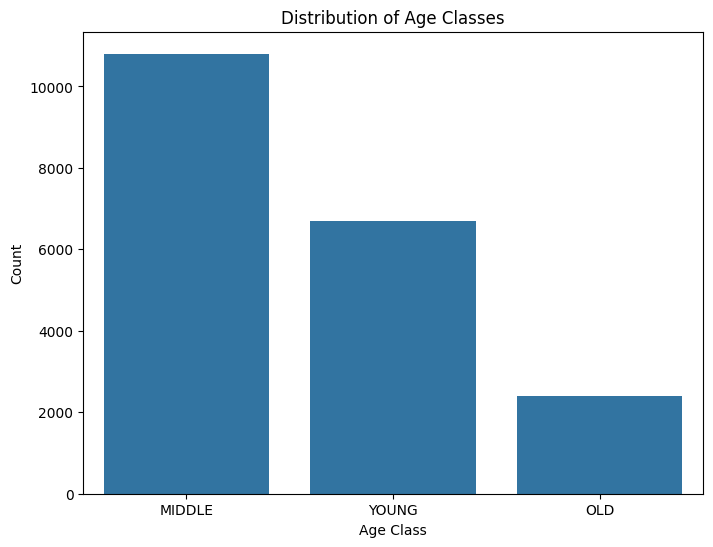

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Class', order=df_train['Class'].value_counts().index)
plt.title('Distribution of Age Classes')
plt.xlabel('Age Class')
plt.ylabel('Count')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assuming image files are in a 'Train' subdirectory within the 'faces' directory
image_dir = os.path.join(dataset_base_path, 'Train')

# Create full paths to the images
df_train['image_path'] = df_train['ID'].apply(lambda x: os.path.join(image_dir, x))

# Encode categorical labels to numerical
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['Class'])

# Display the mapping of original class names to numerical labels
print("\nClass to Label mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {i}")

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    df_train['image_path'],
    df_train['label'],
    test_size=0.2, # 20% for validation
    stratify=df_train['label'], # Maintain class distribution in splits
    random_state=42
)

# Create DataFrames for easier handling with Keras ImageDataGenerator
df_train_split = pd.DataFrame({'image_path': X_train, 'label': y_train})
df_val_split = pd.DataFrame({'image_path': X_val, 'label': y_val})

print(f"\nTraining samples: {len(df_train_split)}")
print(f"Validation samples: {len(df_val_split)}")

print("\nFirst 5 rows of training split with image paths and labels:")
print(df_train_split.head())


Class to Label mapping:
MIDDLE: 0
OLD: 1
YOUNG: 2

Training samples: 15924
Validation samples: 3982

First 5 rows of training split with image paths and labels:
                                              image_path  label
16308  /root/.cache/kagglehub/datasets/arashnic/faces...      0
6623   /root/.cache/kagglehub/datasets/arashnic/faces...      0
2386   /root/.cache/kagglehub/datasets/arashnic/faces...      0
13511  /root/.cache/kagglehub/datasets/arashnic/faces...      2
19198  /root/.cache/kagglehub/datasets/arashnic/faces...      2


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32
NUM_CLASSES = len(label_encoder.classes_)

# Create ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerator for validation (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators from DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train_split,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val_split,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False, # No need to shuffle validation data
    seed=42
)

print("Data generators created successfully.")

Found 15924 validated image filenames.
Found 3982 validated image filenames.
Data generators created successfully.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(NUM_CLASSES, activation='softmax') # Output layer with NUM_CLASSES for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
              metrics=['accuracy'])

# Display the model summary
model.summary()

print("Deep learning model defined and compiled successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Deep learning model defined and compiled successfully.


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=5,            # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

model_checkpoint = ModelCheckpoint(
    'best_model.keras',     # Filepath to save the model
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=True,    # Save only the best model
    mode='max',             # Maximize validation accuracy
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=1, # Start with a reasonable number of epochs, EarlyStopping will stop if no improvement
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, model_checkpoint]
)

print("Model training complete.")

497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5686 - loss: 0.9190
Epoch 1: val_accuracy improved from None to 0.63810, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
497/497 ━━━━━━━━━━━━━━━━━━━━ 220s 443ms/step - accuracy: 0.5799 - loss: 0.8973 - val_accuracy: 0.6381 - val_loss: 0.8388
Model training complete.


In [40]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

# Define image dimensions (must match training)
IMG_WIDTH = 224
IMG_HEIGHT = 224

# Load the trained model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('best_model.keras')
    return model

model = load_model()

# Define class names (must match the order of LabelEncoder)
# Based on previous output: MIDDLE: 0, OLD: 1, YOUNG: 2
class_names = ['MIDDLE', 'OLD', 'YOUNG']

# Define descriptive age ranges for better understanding
age_class_descriptions = {
    'YOUNG': 'Young (e.g., 0-25 years)',
    'MIDDLE': 'Middle Age (e.g., 26-60 years)',
    'OLD': 'Old (e.g., 60+ years)'
}

st.set_page_config(layout="wide", page_title="Age Detection App") # Use 'wide' layout for better column display

st.title("Face Age Detector")
st.markdown("Upload an image of a face to see its predicted age class and confidence levels.")

with st.expander("**Click here to understand the Age Categories**"):
    st.markdown(f"*   **Young**: {age_class_descriptions['YOUNG']}")
    st.markdown(f"*   **Middle Age**: {age_class_descriptions['MIDDLE']}")
    st.markdown(f"*   **Old**: {age_class_descriptions['OLD']}")
st.markdown("--- ")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')

    # Create two columns for better layout
    col1, col2 = st.columns(2)

    with col1:
        st.image(image, caption='Uploaded Image')
        st.write("")

    with st.spinner('Classifying...'):
        # Preprocess the image
        image_resized = image.resize((IMG_WIDTH, IMG_HEIGHT))
        img_array = np.array(image_resized)
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        img_array = img_array / 255.0 # Normalize pixel values

        # Make prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_index]
        confidence = np.max(predictions[0]) * 100

    # Get the descriptive text for the predicted class
    descriptive_prediction = age_class_descriptions.get(predicted_class_name, predicted_class_name)

    with col1:
        st.success(f"Prediction: **{descriptive_prediction}** with {confidence:.2f}% confidence.")

    with col2:
        st.markdown("### Prediction Confidence")
        # Create a DataFrame for plotting
        confidence_df = pd.DataFrame({
            'Age Class': [age_class_descriptions.get(cn, cn) for cn in class_names],
            'Confidence': predictions[0]
        })
        # Sort for better visualization
        confidence_df = confidence_df.sort_values(by='Confidence', ascending=False)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(confidence_df['Age Class'], confidence_df['Confidence'], color=['skyblue', 'lightcoral', 'lightgreen'])
        ax.set_ylim(0, 1)
        ax.set_ylabel('Probability')
        ax.set_title('Model Confidence for Each Age Class')
        st.pyplot(fig)


Overwriting app.py


### How to run the Streamlit app:

1.  **Install Streamlit** (if you haven't already):
    ```bash
    !pip install streamlit
    ```
2.  **Run the app from your local machine (recommended for interactive use)**:
    *   Download the `app.py` file to your computer.
    *   Open your terminal or command prompt.
    *   Navigate to the directory where you saved `app.py`.
    *   Run the command: `streamlit run app.py`
    *   This will open a new tab in your web browser with the Streamlit application.

3.  **Run the app directly in Colab (for demonstration purposes, might require Ngrok or similar for public access)**:
    This method can be a bit more involved if you want a publicly accessible link. For a quick local preview within Colab, you can use `!streamlit run app.py & npx localtunnel --port 8501` and then follow the link provided by localtunnel. However, running Streamlit locally on your machine provides a smoother experience.



In [14]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 111.5 MB/s eta 0:00:00


In [15]:
!pip install streamlit pyngrok

In [16]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [41]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &

2026-08-12 14:05:21.825 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.6.45.193:8501

2026-08-12 14:05:29.758895: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1786543529.761244    7753 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11585 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786543544.414507    7787 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
